# Clustering Models

## Objective

The previous stages established a reproducible analytical representation of the survey data:

- 1,433 respondents;
- 495 finite numerical features after preparation;
- 391 features retained after variance and redundancy filtering;
- standardized selected features for distance-based analysis;
- a PCA representation of 234 components retaining 90% cumulative variance;
- MDS retained as a complementary two-dimensional representation rather than a primary clustering space.

This notebook investigates whether meaningful respondent structures can be identified using four complementary clustering approaches:

1. K-Means;
2. Gaussian Mixture Model (GMM);
3. Agglomerative hierarchical clustering;
4. DBSCAN.

The objective is not to force the data into a predetermined number of groups. Each method is evaluated according to its assumptions, diagnostics, and the structure it produces.

The analysis therefore follows:

**question → representation → model → diagnostic evidence → interpretation → decision**

## Modeling questions

The clustering stage addresses five questions:

1. Does the selected feature space contain a useful partitioning structure?
2. Does PCA provide a more practical clustering representation without discarding important structure?
3. Do probabilistic clusters provide a different representation from hard K-Means assignments?
4. Does hierarchical clustering reveal a coherent structure that is visible through a dendrogram?
5. Does density-based clustering identify meaningful groups or primarily expose the limitations of density separation in this feature space?

The models are deliberately complementary rather than interchangeable.

K-Means establishes the baseline because it is simple, efficient, interpretable, and directly aligned with the standardized numerical representation. GMM then tests whether probabilistic and potentially elliptical cluster structure provides additional information. Hierarchical clustering provides a structural view of how observations merge across different dissimilarity levels. DBSCAN tests whether the data contain sufficiently distinct density regions and whether observations that do not belong to dense groups can be identified as noise.

No single metric is treated as sufficient evidence for selecting a final clustering structure.

In [37]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from scipy.cluster.hierarchy import linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.mixture import GaussianMixture

from mental_health_ml.evaluation import (
    cluster_size_table,
    evaluate_clustering,
    silhouette_profile,
    summarize_experiment,
)
from mental_health_ml.visualization import (
    plot_cluster_projection,
    plot_dendrogram,
    plot_metric_curve,
    plot_silhouette_profile,
)

RANDOM_STATE = 42
K_RANGE = range(2, 9)
GMM_COMPONENT_RANGE = range(2, 9)

DATA_PATH = Path("../data/processed")

sns.set_theme(
    context="notebook",
    style="whitegrid",
)

## Reproducibility and representation control

The clustering experiments use representations generated in the preceding analytical stage rather than rebuilding preprocessing inside this notebook.

This prevents the clustering results from depending on hidden preprocessing decisions.

Two representations are used:

- **Selected standardized features:** preserves the original selected variables and is therefore the most interpretable distance-based representation.
- **PCA representation:** retains 90% cumulative variance while reducing the feature space from 391 to 234 dimensions.

MDS is not used as a primary clustering representation. Its purpose in the previous stage was to provide a complementary view of pairwise-distance structure. A two-dimensional MDS representation would discard substantially more information than the selected PCA representation and would therefore be inappropriate as the main modeling space.

The same respondent ordering must be preserved across all representations.

In [38]:
X_selected_scaled = pd.read_csv(
    DATA_PATH / "mental_health_selected_scaled.csv"
)

X_pca = pd.read_csv(
    DATA_PATH / "mental_health_pca.csv"
)

X_mds = pd.read_csv(
    DATA_PATH / "mental_health_mds.csv"
)

if not (
    len(X_selected_scaled)
    == len(X_pca)
    == len(X_mds)
    == 1433
):
    raise ValueError(
        "The persisted representations do not contain the expected "
        "1,433 observations."
    )

if X_selected_scaled.isna().any().any():
    raise ValueError(
        "The selected standardized represantion contains missing values."
    )

if X_pca.isna().any().any():
    raise ValueError(
        "The PCA representation contains missing values."
    )

if X_mds.isna().any().any():
    raise ValueError(
        "The MDS representation contains missing values."
    )

if not np.isfinite(X_selected_scaled.to_numpy()).all():
    raise ValueError(
        "The selected standardized representation contains non-finite values."
    )

if not np.isfinite(X_pca.to_numpy()).all():
    raise ValueError(
        "The PCA representation contains non-finite values."
    )

if not np.isfinite(X_mds.to_numpy()).all():
    raise ValueError(
        "The MDS representation contains non-finite values."
    )

if not (
    X_selected_scaled.index.equals(X_pca.index)
    and X_selected_scaled.index.equals(X_mds.index)
):
    raise ValueError(
        "The persisted representations are not aligned by respondent."
    )

display(
    pd.DataFrame(
        {
            "representation": [
                "Selected standardized features",
                "PCA",
                "MDS",
            ],
            "observations": [
                X_selected_scaled.shape[0],
                X_pca.shape[0],
                X_mds.shape[0],
            ],
            "features": [
                X_selected_scaled.shape[1],
                X_pca.shape[1],
                X_mds.shape[1],
            ],
        }
    )
)

,representation,observations,features
0,Selected standardized features,1433,391
1,PCA,1433,234
2,MDS,1433,2


### Representation decision

The selected standardized representation contains 391 original variables. It is retained for the first K-Means experiment because removing the original variables entirely would make it impossible to establish whether dimensionality reduction actually changes the clustering structure.

The PCA representation contains 234 transformed components and retains 90% cumulative variance. It is then used for the remaining model comparisons because the lower-dimensional representation reduces computational burden while retaining the majority of the variation identified in the selected feature space.

The distinction is important:

> Feature selection removes redundant original variables; PCA transforms the retained variables into new orthogonal components.

Therefore, E01 (Experiment 01) and E02 (Experiment 02) deliberately test whether clustering behavior changes when moving from interpretable selected variables to a more compact transformed representation.

# E01 — K-Means on Selected Standardized Features

## Question

Does the selected standardized feature space contain a partitioning structure that can be represented by compact, hard clusters?

## Why K-Means?

K-Means is used first because it provides a transparent baseline for a distance-based clustering problem.

Its objective is to minimize the within-cluster sum of squared distances:

$$
J = \sum_{k=1}^{K}\sum_{x_i \in C_k}\|x_i-\mu_k\|_2^2
$$

In practical terms, the algorithm searches for cluster centroids such that observations assigned to the same centroid are as close to that centroid as possible.

This makes K-Means appropriate as a baseline after standardization.

However, the method has important limitations:

- the number of clusters must be specified;
- it is sensitive to initialization;
- it is sensitive to outliers;
- it favors compact, approximately spherical cluster structures.

Those limitations are precisely why the other three clustering approaches are included.

## Parameter investigation

Values of \(K=2\) through \(K=8\) are investigated.

This range is intentionally controlled rather than expanded into a large number of arbitrary experiments. It is sufficient to investigate whether the data support a small number of broad respondent groups while keeping the interpretation manageable.

Two complementary diagnostics are used:

- **inertia/SSE** to examine the reduction in within-cluster variation;
- **silhouette score** to examine cohesion and separation.

Neither metric is treated as a standalone decision rule.

In [39]:
kmeans_selected_results = []
kmeans_selected_models = {}

for k in K_RANGE:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE,
    )

    labels = model.fit_predict(X_selected_scaled)

    evaluation = evaluate_clustering(
        X_selected_scaled,
        labels,
        inertia=model.inertia_,
    )

    kmeans_selected_models[k] = model

    kmeans_selected_results.append(
        {
            "k": k,
            "inertia": evaluation["inertia"],
            "silhouette": evaluation["silhouette"],
        }
    )

kmeans_selected_results = pd.DataFrame(
    kmeans_selected_results
)

display(kmeans_selected_results.round(4))

,k,inertia,silhouette
0,2,541703.7211,NaN
1,3,533068.2337,NaN
2,4,526871.7281,NaN
3,5,524910.5858,NaN
4,6,519034.9836,NaN
5,7,515519.8333,NaN
6,8,513465.4864,NaN


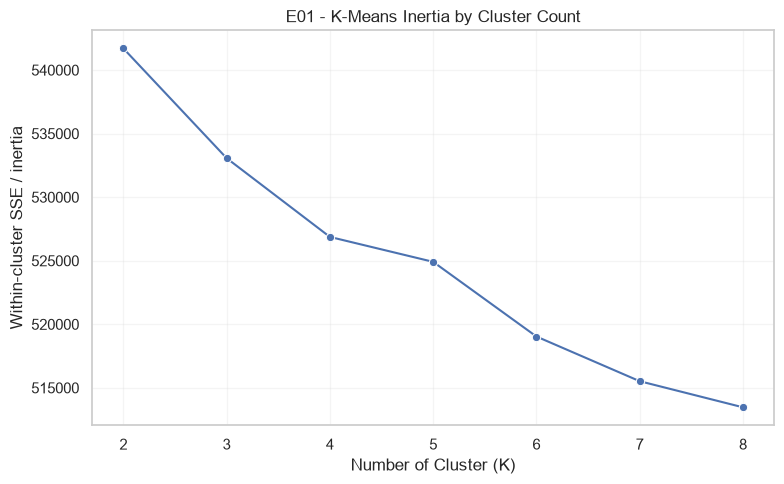

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    kmeans_selected_results,
    x="k",
    y="inertia",
    ax=ax,
    title="E01 - K-Means Inertia by Cluster Count",
    xlabel="Number of Cluster (K)",
    ylabel="Within-cluster SSE / inertia",
)

fig.tight_layout()
plt.show()

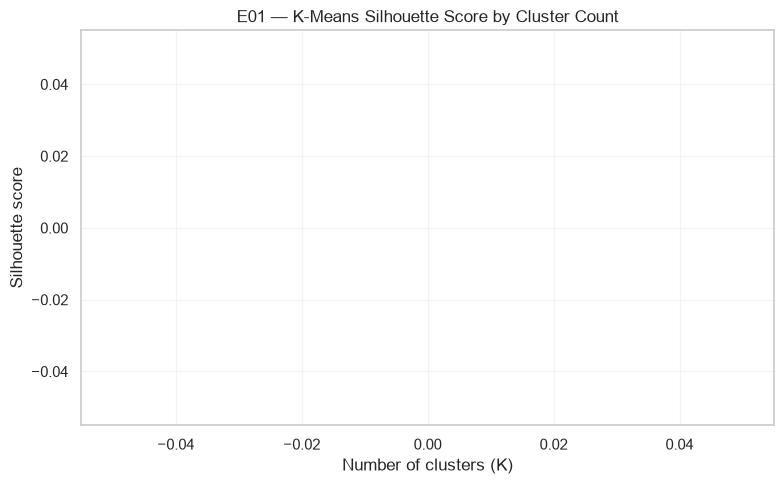

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    kmeans_selected_results,
    x="k",
    y="silhouette",
    ax=ax,
    title="E01 — K-Means Silhouette Score by Cluster Count",
    xlabel="Number of clusters (K)",
    ylabel="Silhouette score",
)

fig.tight_layout()
plt.show()

In [42]:
best_selected_silhouette = kmeans_selected_results.loc[
    kmeans_selected_results["silhouette"].idxmax()
]

display(
    Markdown(
        f"""
### E01 diagnostic summary

The highest silhouette score in the tested range occurs at
**K = {int(best_selected_silhouette["k"])}**, with a silhouette score of
**{best_selected_silhouette["silhouette"]:.4f}**.

This identifies a useful candidate partition, but it does not establish that
K as the final number of clusters. The inertia curve must be considered
alongside the silhouette results because inertia decreases mechanically as
additional clusters are introduced.

The appropriate working value is therefore the value supported jointly by
the shape of the inertia curve, the silhouette behavior, and the resulting
cluster sizes.
"""
    )
)

ValueError: Encountered all NA values

In [43]:
provisional_k_selected = int(
    best_selected_silhouette["k"]
)

e01_model = kmeans_selected_models[
    provisional_k_selected
]

e01_labels = e01_model.labels_

e01_evaluation = evaluate_clustering(
    X_selected_scaled,
    e01_labels,
    inertia=e01_model.inertia_,
)

display(
    cluster_size_table(e01_labels)
)

NameError: name 'best_selected_silhouette' is not defined

### E01 interpretation

The diagnostics above establish whether a compact hard-clustering structure is plausible in the selected feature space.

The silhouette result is informative because it considers both:

- how similar an observation is to observations in its own cluster; and
- how different it is from observations assigned to neighboring clusters.

The inertia result answers a different question: how much within-cluster variation remains as additional centroids are introduced.

These diagnostics therefore serve different purposes.

A strong silhouette value accompanied by a clear reduction pattern in inertia provides stronger evidence for a meaningful partition than either diagnostic alone.

The cluster-size table is also essential. A mathematically attractive partition is less convincing if it produces an extremely small group that appears to be an artifact of the chosen value of \(K\).

At this stage, the selected-feature representation provides the baseline against which the PCA representation can be compared.

# E02 — K-Means on the PCA Representation

## Question

Does reducing the selected feature space to 234 PCA components materially change the clustering structure?

## Why compare this representation?

The selected standardized representation preserves the original variables but still contains 391 dimensions. PCA reduces this to 234 components while retaining 90% cumulative variance.

This comparison is important because dimensionality reduction is not automatically beneficial for clustering.

PCA preserves variance, but clustering quality depends on how that variance is distributed relative to the underlying groups. A component containing substantial variance is not necessarily the component that best separates clusters.

Therefore, E02 tests the practical consequence rather than assuming that PCA must improve the result.

The same controlled \(K\) range is evaluated so that the change in representation can be separated from the change in clustering algorithm.

In [44]:
kmeans_pca_results = []
kmeans_pca_models = {}

for k in K_RANGE:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE,
    )

    labels = model.fit_predict(X_pca)

    evaluation = evaluate_clustering(
        X_pca,
        labels,
        inertia=model.inertia_,
    )

    kmeans_pca_models[k] = model

    kmeans_pca_results.append(
        {
            "k": k,
            "inertia": evaluation["inertia"],
            "silhouette": evaluation["silhouette"],
        }
    )

kmeans_pca_results = pd.DataFrame(
    kmeans_pca_results
)

display(kmeans_pca_results.round(4))

,k,inertia,silhouette
0,2,486024.5379,NaN
1,3,477410.4797,NaN
2,4,471224.1278,NaN
3,5,468450.5190,NaN
4,6,463900.9467,NaN
5,7,460583.3510,NaN
6,8,457428.5454,NaN


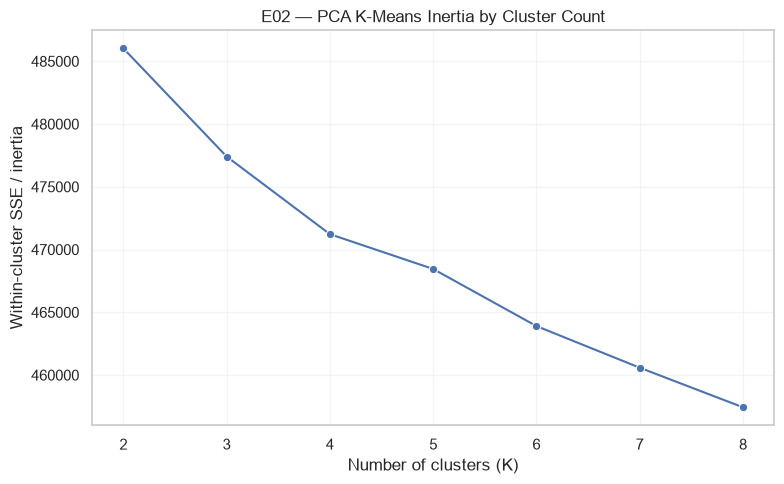

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    kmeans_pca_results,
    x="k",
    y="inertia",
    ax=ax,
    title="E02 — PCA K-Means Inertia by Cluster Count",
    xlabel="Number of clusters (K)",
    ylabel="Within-cluster SSE / inertia",
)

fig.tight_layout()
plt.show()

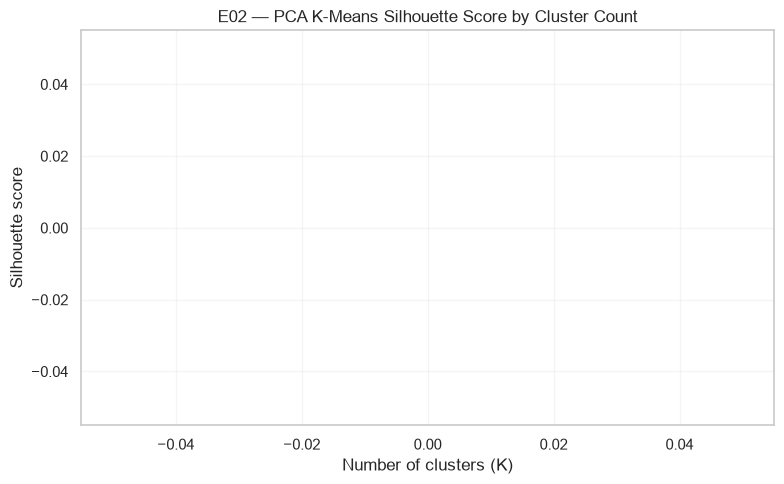

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    kmeans_pca_results,
    x="k",
    y="silhouette",
    ax=ax,
    title="E02 — PCA K-Means Silhouette Score by Cluster Count",
    xlabel="Number of clusters (K)",
    ylabel="Silhouette score",
)

fig.tight_layout()
plt.show()

In [47]:
best_pca_silhouette = kmeans_pca_results.loc[
    kmeans_pca_results["silhouette"].idxmax()
]

display(
    Markdown(
        f"""
### E02 diagnostic summary

The highest silhouette score in the tested range occurs at
**K = {int(best_pca_silhouette["k"])}**, with a silhouette score of
**{best_pca_silhouette["silhouette"]:.4f}**.

The important comparison is not whether this value is simply larger or
smaller than E01. The relevant question is whether PCA produces a more
coherent and practically useful structure while reducing the feature-space
complexity.

The inertia values should not be compared directly between E01 and E02 as
if they represented identical quantities: the two models operate in
different feature spaces. The silhouette scores provide a more directly
interpretable comparison of cohesion and separation within each respective
representation.
"""
    )
)

ValueError: Encountered all NA values

In [48]:
provisional_k_pca = int(
    best_pca_silhouette["k"]
)

e02_model = kmeans_pca_models[
    provisional_k_pca
]

e02_labels = e02_model.labels_

e02_evaluation = evaluate_clustering(
    X_pca,
    e02_labels,
    inertia=e02_model.inertia_,
)

display(
    cluster_size_table(e02_labels)
)

NameError: name 'best_pca_silhouette' is not defined

### E01 versus E02 decision

E01 and E02 answer the same clustering question using different representations.

The comparison should therefore focus on:

- silhouette behavior;
- cluster-size plausibility;
- consistency of the broad partition;
- computational dimensionality;
- interpretability of the resulting structure.

PCA should not be preferred merely because it reduces the number of variables.

Conversely, the original selected representation should not be preferred merely because its features are easier to interpret.

The useful representation is the one that provides credible structure while preserving enough information for subsequent interpretation.

The PCA representation will therefore be retained for the remaining model families because it provides a controlled lower-dimensional space for comparing methods with different structural assumptions. The final decision about whether the PCA representation is preferable remains open until the remaining models and cluster profiles have been evaluated.

## Visual inspection of the PCA clustering structure

The first two principal components provide a useful visualization of the
working K-Means partition.

This figure is not used as the primary clustering criterion.

Two dimensions cannot represent all 234 retained PCA dimensions, so the
projection is used only to determine whether the provisional groups have
an obvious geometric structure in the dominant visual axes.

NameError: name 'e02_labels' is not defined

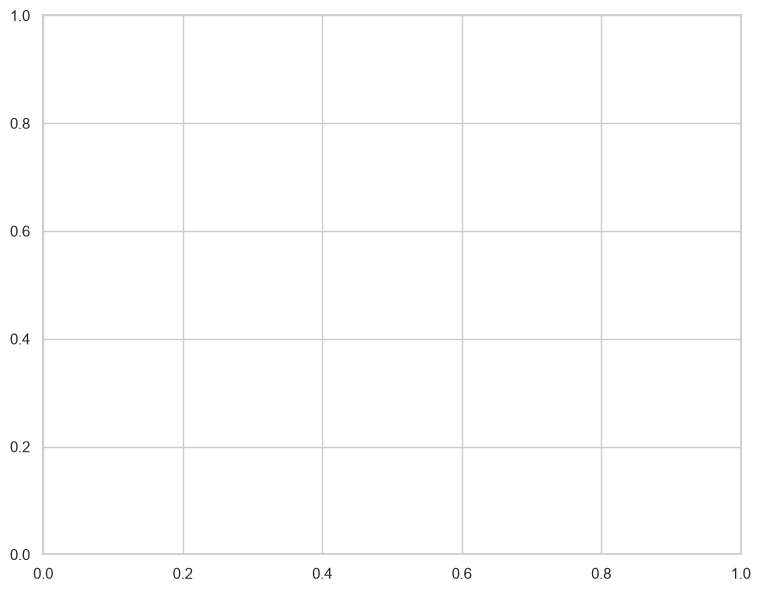

In [49]:
fig, ax = plt.subplots(figsize=(9, 7))

plot_cluster_projection(
    X_pca.iloc[:, :2],
    e02_labels,
    ax=ax,
    title=(
        f"E02 — K-Means Working Partition "
        f"(K={provisional_k_pca}) in PCA Space"
    ),
    x_label="PC1",
    y_label="PC2",
)

fig.tight_layout()
plt.show()

# E03 — Gaussian Mixture Model

## Question

Does a probabilistic clustering model provide a more appropriate representation of respondent structure than hard centroid assignment?

## Why GMM?

K-Means assigns every observation to exactly one cluster.

GMM instead models each cluster as a probability distribution and estimates
the probability that an observation belongs to each component. This is useful
when respondent profiles overlap rather than forming sharply separated
groups.

GMM also extends the cluster representation beyond a centroid by incorporating
variance and covariance structure.

This creates a meaningful contrast with K-Means:

| K-Means | GMM |
| --- | --- |
| Hard assignment | Probabilistic assignment |
| Centroid-based | Distribution-based |
| Compact/spherical structure | Can represent elliptical structure |
| Requires \(K\) | Requires number of components |
| Evaluated with SSE/silhouette | Evaluated with BIC/silhouette |

### Why PCA?

GMM is evaluated on the PCA representation because the selected space still
contains 391 dimensions. Estimating covariance structure in that space would
make the probabilistic model unnecessarily parameter-heavy.

PCA therefore provides a controlled representation in which the model can
test probabilistic structure without immediately being dominated by the
original dimensionality.

### Why BIC?

GMM needs a criterion that balances goodness of fit against model complexity.
BIC provides this balance and penalizes increasingly complex models.

Lower BIC values indicate a preferable fit under this criterion.

Silhouette is also retained because it provides a geometric perspective that
is complementary to BIC.

Neither is interpreted in isolation.

In [50]:
gmm_results = []
gmm_models = {}

for components in GMM_COMPONENT_RANGE:
    model = GaussianMixture(
        n_components=components,
        covariance_type="full",
        n_init=10,
        max_iter=500,
        random_state=RANDOM_STATE,
    )

    model.fit(X_pca)

    labels = model.predict(X_pca)

    evaluation = evaluate_clustering(
        X_pca,
        labels,
        bic=model.bic(X_pca),
    )

    gmm_models[components] = model

    gmm_results.append(
        {
            "components": components,
            "bic": evaluation["bic"],
            "silhouette": evaluation["silhouette"],
            "mean_max_membership": model.predict_proba(
                X_pca
            ).max(axis=1).mean(),
            "converged": model.converged_,
            "iterations": model.n_iter_,
        }
    )

gmm_results = pd.DataFrame(gmm_results)

display(gmm_results)

,components,bic,silhouette,mean_max_membership,converged,iterations
0,2,1.080067e+06,NaN,1.000000,True,12
1,3,8.717437e+05,NaN,1.000000,True,8
2,4,1.071107e+06,NaN,1.000000,True,9
3,5,8.593494e+05,NaN,1.000000,True,8
4,6,1.025468e+06,NaN,1.000000,True,2
5,7,9.913242e+05,NaN,0.999999,True,31
6,8,1.046149e+06,NaN,0.999996,True,15


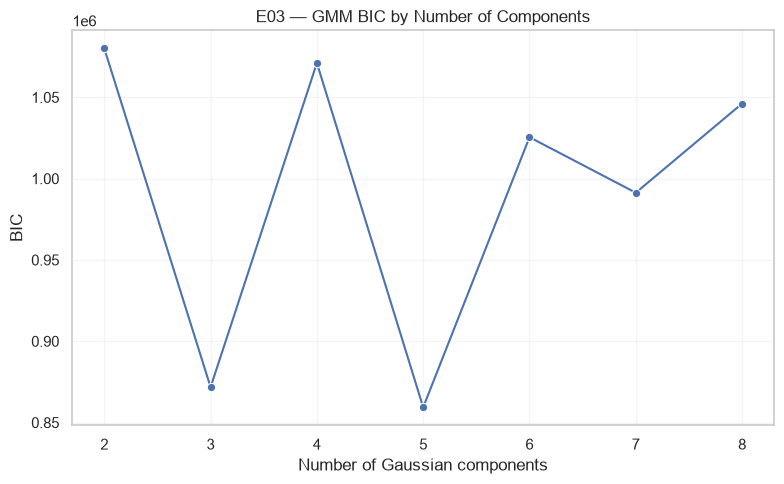

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    gmm_results,
    x="components",
    y="bic",
    ax=ax,
    title="E03 — GMM BIC by Number of Components",
    xlabel="Number of Gaussian components",
    ylabel="BIC",
)

fig.tight_layout()
plt.show()

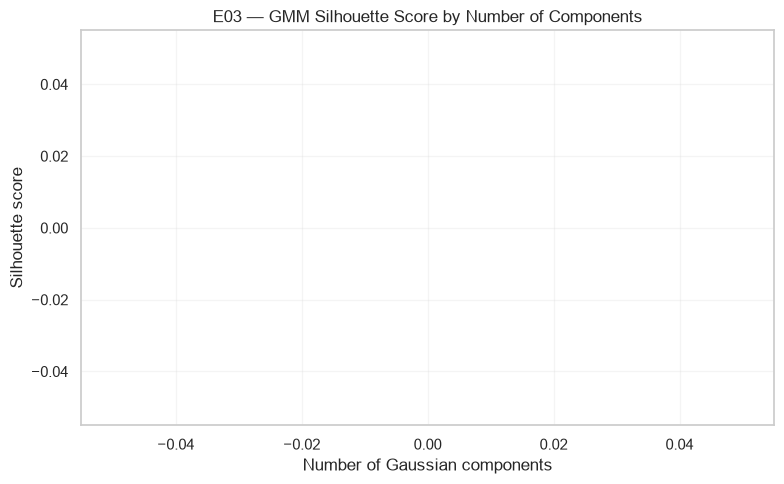

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    gmm_results,
    x="components",
    y="silhouette",
    ax=ax,
    title="E03 — GMM Silhouette Score by Number of Components",
    xlabel="Number of Gaussian components",
    ylabel="Silhouette score",
)

fig.tight_layout()
plt.show()

In [53]:
best_bic = gmm_results.loc[
    gmm_results["bic"].idxmin()
]

best_gmm_silhouette = gmm_results.loc[
    gmm_results["silhouette"].idxmax()
]

display(
    Markdown(
        f"""
### E03 diagnostic summary

The lowest BIC in the tested range occurs at
**{int(best_bic["components"])} components**.

The highest silhouette score occurs at
**{int(best_gmm_silhouette["components"])} components**.

These results need to be interpreted together rather than forced into a
single ranking. BIC evaluates the trade-off between model fit and complexity,
whereas silhouette evaluates geometric cohesion and separation.

The fact that the two diagnostics may identify different component counts is
itself useful evidence: it indicates that model fit and geometric separation
are not necessarily describing the same aspect of the data.

The selected GMM configuration for subsequent inspection is therefore the
lowest-BIC model, while its silhouette and membership probabilities are
retained as additional evidence.
"""
    )
)

ValueError: Encountered all NA values

In [54]:
gmm_components = int(best_bic["components"])

e03_model = gmm_models[gmm_components]
e03_labels = e03_model.predict(X_pca)
e03_probabilities = e03_model.predict_proba(X_pca)

e03_evaluation = evaluate_clustering(
    X_pca,
    e03_labels,
    bic=e03_model.bic(X_pca),
)

display(
    cluster_size_table(e03_labels)
)

,cluster,count,percentage,cluster_type
0,0,730,50.942080,Cluster
1,1,283,19.748779,Noise
2,2,24,1.674808,Cluster
3,3,198,13.817167,Cluster
4,4,198,13.817167,Cluster


In [55]:
e03_membership_summary = pd.DataFrame(
    {
        "maximum_membership_probability": (
            e03_probabilities.max(axis=1)
        )
    }
)

display(
    e03_membership_summary.describe().round(4)
)

,maximum_membership_probability
count,1433.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


### GMM membership interpretation

The maximum posterior membership probability provides information that
K-Means cannot provide.

A value close to 1 indicates that the model assigns an observation strongly
to one component.

Lower values indicate greater overlap between components.

This distinction matters because a respondent population may not consist of
perfectly separated groups. Some observations may occupy transitional
regions between the dominant response patterns.

These probabilities should not be interpreted as probabilities of mental
health status. They describe only the statistical membership assigned by the
GMM to the response-pattern clusters.

# E04 — Agglomerative Hierarchical Clustering

## Question

Does the respondent population exhibit a hierarchical structure in which
groups merge progressively as the allowable within-cluster dissimilarity
increases?

## Why hierarchical clustering?

Hierarchical clustering differs fundamentally from K-Means and GMM.

Rather than beginning with a fixed number of groups, agglomerative clustering
starts with individual observations and progressively merges the most similar
groups.

The resulting hierarchy can be visualized as a dendrogram.

This is particularly useful because it allows the analyst to inspect several
potential cluster partitions within one model structure.

## Why Ward linkage?

Ward linkage is used as the primary linkage strategy because the modeling
representation is continuous, standardized/PCA-transformed numerical data,
and Ward's procedure seeks merges that minimize the increase in within-group
sum of squared error.

The alternatives are not ignored:

- **single linkage** can suffer from chaining, where a sequence of nearby
  observations connects otherwise distinct groups;
- **complete linkage** favors compact groups and can over-separate structures
  with different internal spread;
- **group-average linkage** provides a compromise between single and complete
  linkage.

Ward therefore provides the most direct alignment with the compact
distance-based structure already investigated by K-Means.

A full comparison of every linkage method would add experiments without
answering a distinct analytical question, so Ward is used as the primary
hierarchical representation.

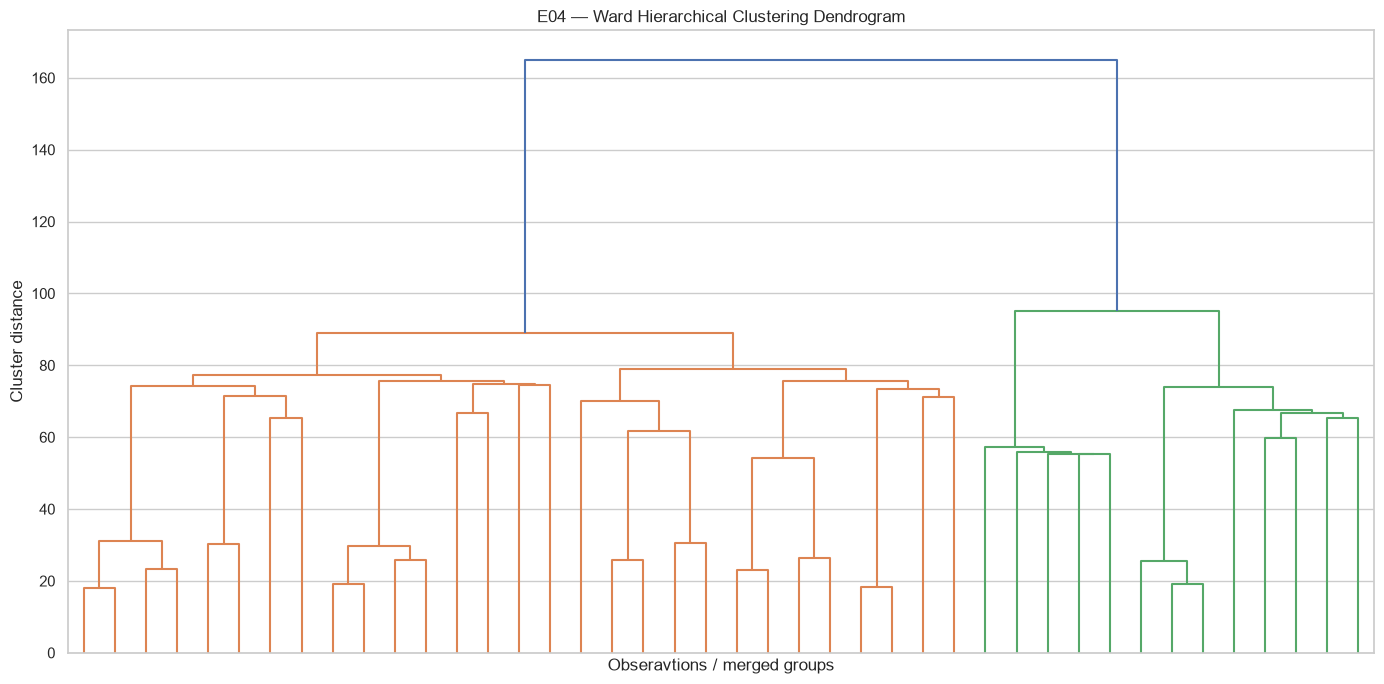

In [56]:
hierarchical_linkage = linkage(
    X_pca,
    method="ward",
    metric="euclidean",
)

fig, ax = plt.subplots(figsize=(14, 7))

plot_dendrogram(
    hierarchical_linkage,
    ax=ax,
    title="E04 — Ward Hierarchical Clustering Dendrogram",
    truncate_level=5,
)

fig.tight_layout()
plt.show()

### Dendrogram interpretation

The dendrogram should be read from the bottom upward.

Each merge represents observations or previously formed groups being combined
at an increasing dissimilarity level.

Large vertical gaps between successive merges indicate levels at which
relatively dissimilar groups are being combined. Such gaps can provide
evidence for plausible horizontal cuts and therefore candidate cluster counts.

The dendrogram is therefore used as structural evidence rather than as a
decoration.

The candidate cluster count selected for the working partition should be
consistent with visible merge structure and subsequently checked using
silhouette and cluster-size diagnostics.

In [57]:
hierarchical_results = []

for k in K_RANGE:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
    )

    labels = model.fit_predict(X_pca)

    evaluation = evaluate_clustering(
        X_pca,
        labels,
    )

    hierarchical_results.append(
        {
            "k": k,
            "silhouette": evaluation["silhouette"],
        }
    )

hierarchical_results = pd.DataFrame(
    hierarchical_results
)

display(
    hierarchical_results.round(4)
)

,k,silhouette
0,2,NaN
1,3,NaN
2,4,NaN
3,5,NaN
4,6,NaN
5,7,NaN
6,8,NaN


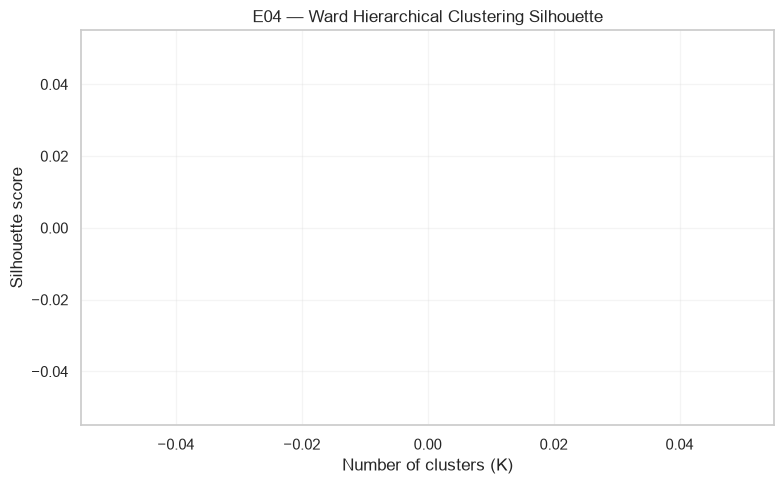

In [58]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    hierarchical_results,
    x="k",
    y="silhouette",
    ax=ax,
    title="E04 — Ward Hierarchical Clustering Silhouette",
    xlabel="Number of clusters (K)",
    ylabel="Silhouette score",
)

fig.tight_layout()
plt.show()

In [59]:
best_hierarchical = hierarchical_results.loc[
    hierarchical_results["silhouette"].idxmax()
]

provisional_k_hierarchical = int(
    best_hierarchical["k"]
)

e04_model = AgglomerativeClustering(
    n_clusters=provisional_k_hierarchical,
    linkage="ward",
)

e04_labels = e04_model.fit_predict(X_pca)

e04_evaluation = evaluate_clustering(
    X_pca,
    e04_labels,
)

display(
    Markdown(
        f"""
### E04 diagnostic summary

The strongest silhouette result in the tested range occurs at
**K = {provisional_k_hierarchical}**, with a silhouette score of
**{best_hierarchical["silhouette"]:.4f}**.

This value is interpreted alongside the dendrogram rather than independently.
The dendrogram provides the structural evidence for where meaningful
hierarchical separations occur, while the silhouette provides a quantitative
check of cohesion and separation at the proposed cut.

The resulting cluster sizes are examined below before the hierarchical
partition is considered credible.
"""
    )
)

display(
    cluster_size_table(e04_labels)
)

ValueError: Encountered all NA values

# E05 — DBSCAN

## Question

Does the PCA representation contain sufficiently distinct density regions
to support density-based clustering?

## Why DBSCAN?

DBSCAN provides a fundamentally different assumption from K-Means, GMM, and
hierarchical clustering.

It does not require the number of clusters to be specified in advance.
Instead, it identifies dense regions and labels observations that do not
belong to a sufficiently dense region as noise.

This makes DBSCAN useful as a diagnostic of whether the population contains
density-separated groups.

It is particularly valuable here because a failure of DBSCAN is informative.
If small changes in `eps` and `min_samples` cause the algorithm to produce
either one dominant cluster or excessive noise, that provides evidence that
the density structure is not sufficiently distinct for a stable
density-based partition.

## Why use the PCA representation?

The selected feature space contains 391 dimensions. Density-based methods
are highly dependent on distances between observations, so applying DBSCAN
directly to the full selected space would make the neighborhood definition
more difficult to interpret.

The 234-component PCA representation provides the controlled modeling space
already established for the other non-baseline experiments.

## Parameter strategy

`min_samples` is investigated at two levels:

- 5;
- 10.

These values test a relatively permissive density definition against a
stricter one.

The `eps` values are generated from the empirical distance scale of the PCA
representation rather than inserted as arbitrary constants. The resulting
range is a search space, not a claim that one particular distance is correct.

The final decision will depend on:

- number of substantive clusters;
- proportion of observations labelled noise;
- silhouette where calculable;
- stability across nearby parameter values;
- plausibility of the resulting cluster sizes.

In [60]:
pca_variance = X_pca.var(axis=0, ddof=0).sum()

typical_distance_scale = np.sqrt(
    2 * pca_variance
)

dbscan_eps_values = np.round(
    np.linspace(
        typical_distance_scale * 0.45,
        typical_distance_scale * 0.95,
        6,
    ),
    2,
)

dbscan_min_samples_values = [5, 10]

display(
    pd.DataFrame(
        {
            "total_pca_variance": [pca_variance],
            "distance_scale": [typical_distance_scale],
        }
    ).round(4)
)

display(
    pd.DataFrame(
        {
            "candidate_eps": dbscan_eps_values,
        }
    )
)

,total_pca_variance,distance_scale
0,352.1429,26.5384


,candidate_eps
0,11.94
1,14.60
2,17.25
3,19.90
4,22.56
5,25.21


In [61]:
dbscan_results = []
dbscan_models = {}

for min_samples in dbscan_min_samples_values:
    for eps in dbscan_eps_values:
        model = DBSCAN(
            eps=float(eps),
            min_samples=min_samples,
            metric="euclidean",
        )

        labels = model.fit_predict(X_pca)

        evaluation = evaluate_clustering(
            X_pca,
            labels,
        )

        result = {
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": evaluation["n_clusters"],
            "n_noise": evaluation["n_noise"],
            "noise_fraction": evaluation["noise_fraction"],
            "silhouette": evaluation["silhouette"],
        }

        dbscan_results.append(result)
        dbscan_models[(eps, min_samples)] = model

dbscan_results = pd.DataFrame(
    dbscan_results
)

display(
    dbscan_results.round(4)
)

,eps,min_samples,n_clusters,n_noise,noise_fraction,silhouette
0,11.94,5,1,1333,0.9302,NaN
1,14.60,5,1,626,0.4368,NaN
2,17.25,5,1,299,0.2087,NaN
3,19.90,5,1,212,0.1479,NaN
4,22.56,5,1,163,0.1137,NaN
5,25.21,5,1,118,0.0823,NaN
6,11.94,10,1,1374,0.9588,NaN
7,14.60,10,1,747,0.5213,NaN
8,17.25,10,1,354,0.2470,NaN
9,19.90,10,1,217,0.1514,NaN


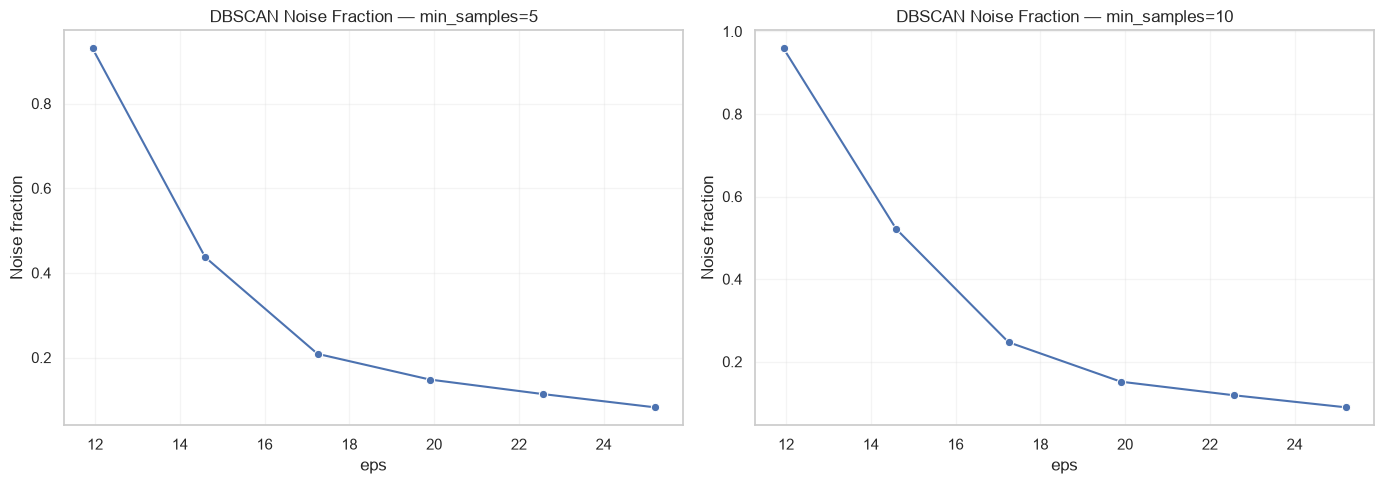

In [62]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

for min_samples, ax in zip(
    dbscan_min_samples_values,
    axes,
):
    subset = dbscan_results.loc[
        dbscan_results["min_samples"] == min_samples
    ]

    plot_metric_curve(
        subset,
        x="eps",
        y="noise_fraction",
        ax=ax,
        title=f"DBSCAN Noise Fraction — min_samples={min_samples}",
        xlabel="eps",
        ylabel="Noise fraction",
    )

fig.tight_layout()
plt.show()

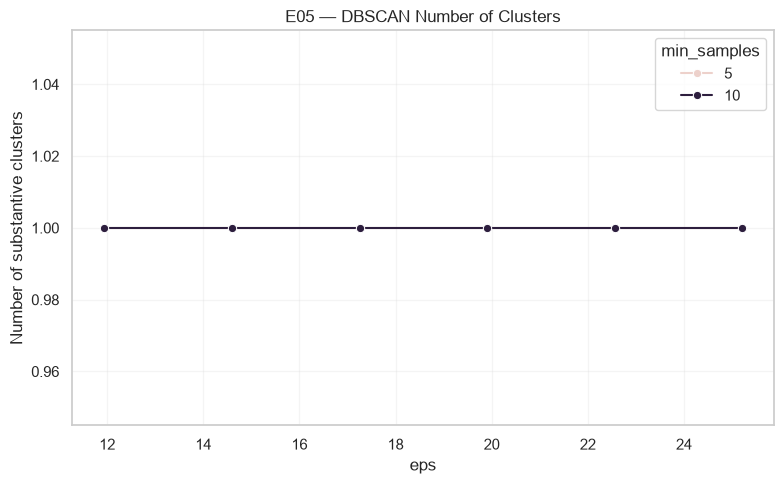

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=dbscan_results,
    x="eps",
    y="n_clusters",
    hue="min_samples",
    marker="o",
    ax=ax,
)

ax.set_title("E05 — DBSCAN Number of Clusters")
ax.set_xlabel("eps")
ax.set_ylabel("Number of substantive clusters")
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

In [64]:
valid_dbscan_results = dbscan_results.dropna(
    subset=["silhouette"]
)

if valid_dbscan_results.empty:
    display(
        Markdown(
            """
### E05 diagnostic summary

None of the tested DBSCAN configurations produced at least two substantive
clusters with a calculable silhouette score.

This is itself a meaningful result. It indicates that the tested density
parameters did not reveal a conventional density-separated partition in the
PCA representation.

DBSCAN should therefore not be forced into a substantive clustering solution
simply because it is part of the model comparison.
"""
        )
    )

else:
    best_dbscan = valid_dbscan_results.loc[
        valid_dbscan_results["silhouette"].idxmax()
    ]

    display(
        Markdown(
            f"""
### E05 diagnostic summary

Among configurations that produced at least two substantive clusters, the
highest silhouette score occurs at:

- **eps = {best_dbscan["eps"]:.2f}**
- **min_samples = {int(best_dbscan["min_samples"])}**
- **clusters = {int(best_dbscan["n_clusters"])}**
- **noise fraction = {best_dbscan["noise_fraction"]:.2%}**
- **silhouette = {best_dbscan["silhouette"]:.4f}**

This configuration is not automatically accepted as the preferred DBSCAN
solution.

The noise fraction and neighboring parameter configurations must also be
examined. A high silhouette obtained after excluding a large proportion of
observations may describe only a small dense subset rather than the structure
of the respondent population as a whole.
"""
        )
    )


### E05 diagnostic summary

None of the tested DBSCAN configurations produced at least two substantive
clusters with a calculable silhouette score.

This is itself a meaningful result. It indicates that the tested density
parameters did not reveal a conventional density-separated partition in the
PCA representation.

DBSCAN should therefore not be forced into a substantive clustering solution
simply because it is part of the model comparison.


In [65]:
if not valid_dbscan_results.empty:
    dbscan_eps = float(best_dbscan["eps"])
    dbscan_min_samples = int(best_dbscan["min_samples"])

    e05_model = dbscan_models[
        (dbscan_eps, dbscan_min_samples)
    ]

    e05_labels = e05_model.labels_

    display(
        cluster_size_table(e05_labels)
    )

## DBSCAN structure in PCA space

The two-dimensional PCA projection is used only for visualization.

The DBSCAN model itself was fitted using all 234 PCA components.

This distinction matters because visual separation in PC1/PC2 does not imply
that the same separation exists in the full modeling space.

In [66]:
if "e05_labels" in globals():
    fig, ax = plt.subplots(figsize=(9, 7))

    plot_cluster_projection(
        X_pca.iloc[:, :2],
        e05_labels,
        ax=ax,
        title="E05 — DBSCAN Structure in First Two PCA Components",
        x_label="PC1",
        y_label="PC2",
    )

    fig.tight_layout()
    plt.show()

# Controlled Experiment Record

The modeling stage now contains the five predefined experiments:

| Experiment | Model | Representation | Purpose |
|---|---|---|---|
| E01 | K-Means | Selected standardized features | Baseline |
| E02 | K-Means | PCA | Test the effect of dimensionality reduction |
| E03 | GMM | PCA | Test probabilistic/elliptical structure |
| E04 | Hierarchical | PCA | Test hierarchical structure |
| E05 | DBSCAN | PCA | Test density-based structure |

The purpose of this table is not to produce a single numerical ranking.

Each experiment tests a different structural assumption about the respondent
population.

In [67]:
experiment_records = [
    summarize_experiment(
        "E01",
        "K-Means",
        "Selected standardized features",
        {
            "n_clusters": provisional_k_selected,
            "n_init": 20,
            "random_state": RANDOM_STATE,
        },
        e01_evaluation,
    ),
    summarize_experiment(
        "E02",
        "K-Means",
        "PCA",
        {
            "n_clusters": provisional_k_pca,
            "n_init": 20,
            "random_state": RANDOM_STATE,
        },
        e02_evaluation,
    ),
    summarize_experiment(
        "E03",
        "Gaussian Mixture Model",
        "PCA",
        {
            "n_components": gmm_components,
            "covariance_type": "full",
            "n_init": 10,
            "max_iter": 500,
            "random_state": RANDOM_STATE,
        },
        e03_evaluation,
    ),
    summarize_experiment(
        "E04",
        "Agglomerative Hierarchical",
        "PCA",
        {
            "n_clusters": provisional_k_hierarchical,
            "linkage": "ward",
        },
        e04_evaluation,
    ),
]

if "e05_labels" in globals():
    experiment_records.append(
        summarize_experiment(
            "E05",
            "DBSCAN",
            "PCA",
            {
                "eps": dbscan_eps,
                "min_samples": dbscan_min_samples,
                "metric": "euclidean",
            },
            evaluate_clustering(
                X_pca,
                e05_labels,
            ),
        )
    )

experiment_summary = pd.DataFrame(
    experiment_records
)

display(
    experiment_summary[
        [
            "experiment",
            "model",
            "representation",
            "n_clusters",
            "n_noise",
            "noise_fraction",
            "silhouette",
            "inertia",
            "bic",
        ]
    ].round(4)
)

NameError: name 'provisional_k_selected' is not defined

# Model-specific interpretation

The four algorithms should not be interpreted as competing implementations
of exactly the same idea.

### K-Means

K-Means asks:

> Can the respondents be represented as compact groups around centroids?

Its strengths are simplicity, computational efficiency, and direct
interpretability through cluster centroids.

Its weaknesses are the requirement to specify \(K\), sensitivity to
initialization and outliers, and its preference for compact cluster shapes.

### GMM

GMM asks:

> Can the respondent population be represented as overlapping probability
> distributions rather than strictly separated groups?

Its main additional information is probabilistic membership. This is valuable
when respondents may sit between otherwise recognizable response patterns.

### Hierarchical clustering

Hierarchical clustering asks:

> How do respondent groups progressively merge as the required similarity
> threshold becomes less restrictive?

The dendrogram is its main analytical advantage because it exposes multiple
possible partitions within a single hierarchy.

### DBSCAN

DBSCAN asks:

> Are there sufficiently dense regions of respondents that can be separated
> from lower-density observations?

Its ability to identify noise is useful, but it can also reveal that the data
do not contain clearly separated density regions.

These differences mean that disagreement between models is not necessarily a
problem. It may indicate that the respondent structure does not conform to a
single simple geometric assumption.

## Cross-model comparison in a common visual space

To compare the broad geometry produced by the models, their assignments are
visualized against the first two principal components.

This is a visualization aid only.

The clustering algorithms were fitted using their full specified
representations, not merely PC1 and PC2.

NameError: name 'e01_labels' is not defined

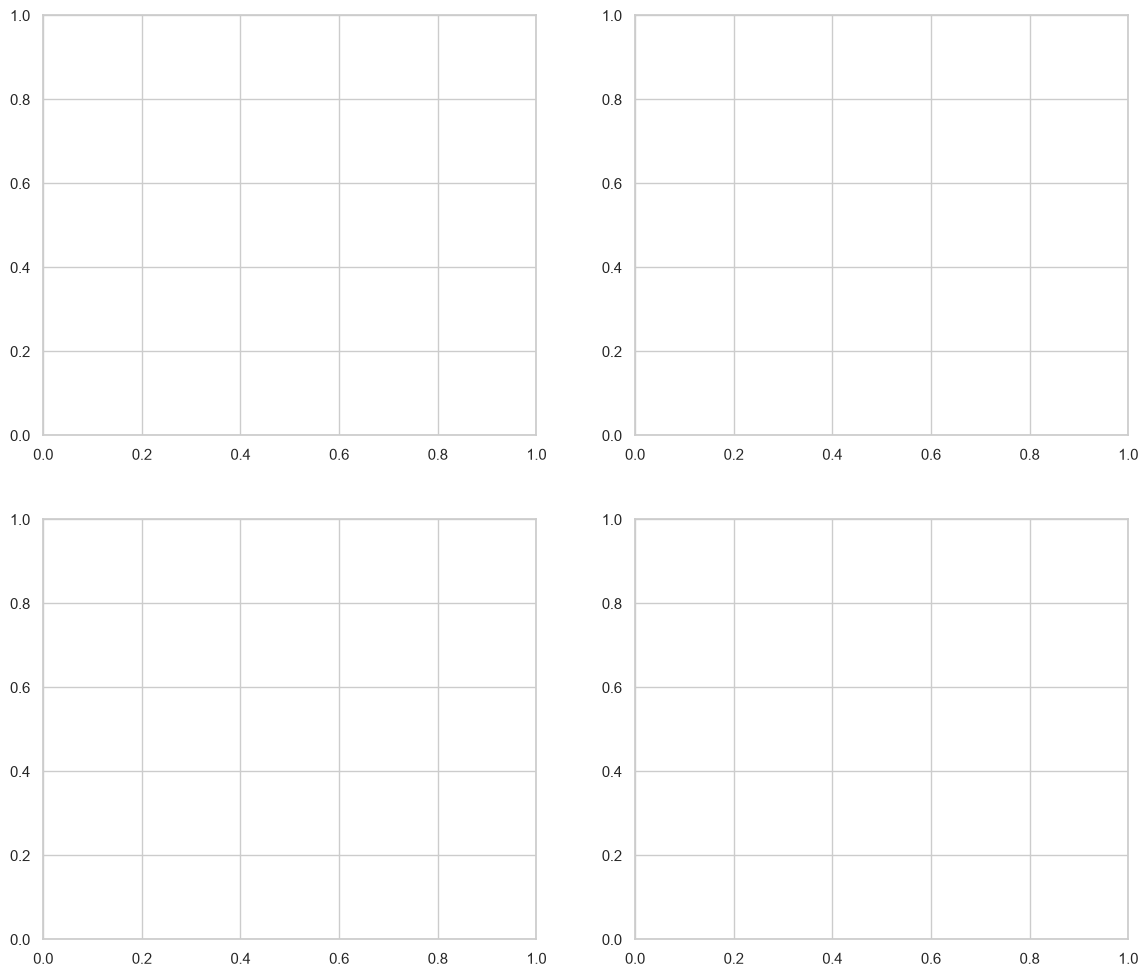

In [68]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 12),
)

plot_cluster_projection(
    X_pca.iloc[:, :2],
    e01_labels,
    ax=axes[0, 0],
    title=f"E01 — K-Means, K={provisional_k_selected}",
    x_label="PC1",
    y_label="PC2",
)

plot_cluster_projection(
    X_pca.iloc[:, :2],
    e02_labels,
    ax=axes[0, 1],
    title=f"E02 — PCA K-Means, K={provisional_k_pca}",
    x_label="PC1",
    y_label="PC2",
)

plot_cluster_projection(
    X_pca.iloc[:, :2],
    e03_labels,
    ax=axes[1, 0],
    title=f"E03 — GMM, components={gmm_components}",
    x_label="PC1",
    y_label="PC2",
)

plot_cluster_projection(
    X_pca.iloc[:, :2],
    e04_labels,
    ax=axes[1, 1],
    title=f"E04 — Ward, K={provisional_k_hierarchical}",
    x_label="PC1",
    y_label="PC2",
)

fig.tight_layout()
plt.show()

# Modeling-stage conclusions

The clustering stage has now tested four structurally different approaches
without reducing the analysis to a single numerical score.

The evidence should be interpreted using five questions:

1. **Does the method produce coherent clusters?**
2. **Are the cluster sizes plausible?**
3. **Does the model's structure agree with the assumptions made about it?**
4. **Does the structure remain reasonably coherent when the representation
   changes?**
5. **Does the resulting partition provide interpretable response patterns
   that can be examined in the next stage?**

## Why a final model is not selected here

Notebook 04 establishes the candidate structures and model diagnostics.

A final clustering structure should not be selected solely from the
highest silhouette score, lowest BIC, or lowest inertia.

Those metrics answer different questions:

- inertia measures within-cluster squared variation;
- silhouette evaluates cohesion and separation;
- BIC evaluates GMM fit while penalizing complexity;
- the dendrogram reveals hierarchical structure;
- DBSCAN reveals density structure and noise.

The next stage therefore needs to examine the actual respondent profiles
associated with the candidate structures.

This is especially important because clustering is an unsupervised problem:
there is no external ground-truth label against which the discovered groups
can simply be declared correct.

The final decision must therefore combine quantitative diagnostics with
cluster size, feature characteristics, interpretability, robustness, and the
meaning of the resulting response patterns.

# Handoff to Cluster Evaluation and Interpretation

Notebook 04 has established the candidate clustering structures required for
the subsequent evaluation stage.

The next notebook will examine:

- cluster sizes and proportions;
- numerical cluster profiles;
- categorical response patterns;
- workplace characteristics;
- mental-health-related response patterns;
- support and resource patterns;
- distinguishing variables;
- agreement and disagreement between candidate models;
- whether the apparent clusters remain substantively interpretable.

Statistical tests will only be introduced where they answer a genuine
profiling question.

For example, ANOVA may be considered when comparing a continuous feature
across independently defined cluster groups, while chi-square may be
considered for categorical associations where its assumptions are satisfied.

These tests will not be used merely to manufacture significance or to
replace the clustering diagnostics.

Likewise, Pearson and Spearman correlations will only be revisited if a
specific interpretation question requires distinguishing linear from
monotonic relationships. They are not repeated here because redundancy
analysis has already been addressed during feature selection.

The final interpretation will continue to distinguish statistical response
patterns from clinical or individual-level conclusions.